# Tiny Deer/Rudolph Detector - YOLOv8 Training Notebook

This notebook trains a lightweight YOLOv8n model to detect deer (including Rudolph) using the Kaggle wildlife 10-class object detection dataset.

**Goal**: Train an edge-efficient YOLO-based model suitable for ~1 hour training on Colab GPU.

**Expected Output**: ONNX model (~5-10 MB) ready for deployment and zkML integration.


## Section 1: Environment Setup

Install required packages and verify GPU availability.


In [9]:
# Install required packages
!pip install ultralytics kagglehub onnx onnxruntime -q

# Verify GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("Warning: No GPU detected. Training will be slow on CPU.")

# Set up project directories
import os
from pathlib import Path

PROJECT_DIR = Path("/content/deer_detector")
PROJECT_DIR.mkdir(exist_ok=True)
DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
DATA_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Model directory: {MODEL_DIR}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 114.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.0 MB/s eta 0:00:00
CUDA available: True
GPU: Tesla T4
CUDA version: 12.6
Project directory: /content/deer_detector
Data directory: /content/deer_detector/data
Model directory: /content/deer_detector/models


## Section 2: Dataset Preparation

Download the Kaggle wildlife 10-class dataset and prepare it for YOLOv8 training.


In [1]:
# Download dataset using kagglehub
import kagglehub

# Download the wildlife 10-class dataset
dataset_path = kagglehub.dataset_download("giotamoraiti/animal-object-detection-dataset-10-classes")
print(f"Dataset downloaded to: {dataset_path}")

# Explore dataset structure
import os
from pathlib import Path

dataset_root = Path(dataset_path)
print(f"\nDataset structure:")
for item in sorted(dataset_root.iterdir()):
    if item.is_dir():
        print(f"  {item.name}/")
        # List first few items in each directory
        items = list(item.iterdir())[:5]
        for subitem in items:
            print(f"    - {subitem.name}")
        if len(list(item.iterdir())) > 5:
            print(f"    ... ({len(list(item.iterdir())) - 5} more items)")


100%|██████████| 2.28G/2.28G [01:48<00:00, 22.6MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1

Dataset structure:
  animals/
    - Fox
    - Squirrel
    - Parrot
    - Raccoon
    - Red panda
    ... (6 more items)


In [2]:
# Find train/val/test directories and verify structure
def find_yolo_dirs(root_path):
    """Find directories containing YOLO format data (images + labels)"""
    yolo_dirs = []
    for item in root_path.rglob("*"):
        if item.is_dir():
            # Check if directory has both images and labels
            has_images = any(f.suffix.lower() in ['.jpg', '.jpeg', '.png'] for f in item.iterdir())
            has_labels = any(f.suffix == '.txt' for f in item.iterdir())
            if has_images or has_labels:
                yolo_dirs.append(item)
    return yolo_dirs

# Common YOLO dataset structures
possible_paths = [
    dataset_root / "train",
    dataset_root / "val",
    dataset_root / "test",
    dataset_root / "images" / "train",
    dataset_root / "images" / "val",
    dataset_root / "labels" / "train",
    dataset_root / "labels" / "val",
]

print("Looking for YOLO dataset structure...")
found_dirs = []
for path in possible_paths:
    if path.exists():
        found_dirs.append(path)
        print(f"Found: {path}")

# If standard structure not found, search recursively
if not found_dirs:
    print("\nSearching recursively...")
    all_dirs = find_yolo_dirs(dataset_root)
    print(f"Found {len(all_dirs)} potential YOLO directories")
    for d in all_dirs[:10]:  # Show first 10
        print(f"  {d}")


Looking for YOLO dataset structure...

Searching recursively...
Found 21 potential YOLO directories
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals/Fox
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals/Squirrel
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals/Parrot
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals/Raccoon
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals/Red panda
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals/Duck
  /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/vers

In [5]:
# Explore the actual dataset structure
import os
from pathlib import Path

dataset_root = Path(dataset_path)
animals_dir = dataset_root / "animals"

# List all animal classes (subdirectories)
if animals_dir.exists():
    class_dirs = [d.name for d in animals_dir.iterdir() if d.is_dir()]
    print(f"Found animal classes: {sorted(class_dirs)}")

    # Check for Deer
    if "Deer" in class_dirs:
        deer_dir = animals_dir / "Deer"
        print(f"\nDeer directory found: {deer_dir}")

        # Count images and labels
        images_dir = deer_dir / "images"
        labels_dir = deer_dir / "labels"

        if images_dir.exists():
            deer_images = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))
            print(f"Deer images: {len(deer_images)}")
        if labels_dir.exists():
            deer_labels = list(labels_dir.glob("*.txt"))
            print(f"Deer labels: {len(deer_labels)}")

            # Show sample label
            if deer_labels:
                print(f"\nSample label ({deer_labels[0].name}):")
                with open(deer_labels[0], 'r') as f:
                    print(f.read()[:200])
    else:
        print("Deer class not found in dataset!")
else:
    print(f"animals directory not found at {animals_dir}")

# We'll train on deer only - single class detection
class_names = ['deer']
print(f"\nTraining on single class: {class_names}")

Found animal classes: ['Bear', 'Deer', 'Duck', 'Fox', 'Parrot', 'Rabbit', 'Raccoon', 'Red panda', 'Squirrel', 'Tiger']

Deer directory found: /root/.cache/kagglehub/datasets/giotamoraiti/animal-object-detection-dataset-10-classes/versions/1/animals/Deer
Deer labels: 521

Sample label (Deer_0288.txt):
1 0.665710 0.572940 0.206180 0.854120

Training on single class: ['deer']


In [7]:
# Prepare deer-only dataset for YOLOv8
# We need to reorganize data into YOLO format and remap class IDs to 0 (single class)

import shutil
import random
import os
from pathlib import Path

# Ensure PROJECT_DIR and other necessary paths are defined
# This is a fallback in case the initial setup cell was not run or kernel was reset
if 'PROJECT_DIR' not in locals():
    PROJECT_DIR = Path("/content/deer_detector")
    DATA_DIR = PROJECT_DIR / "data"
    MODEL_DIR = PROJECT_DIR / "models"
    PROJECT_DIR.mkdir(exist_ok=True)
    DATA_DIR.mkdir(exist_ok=True)
    MODEL_DIR.mkdir(exist_ok=True)
    print(f"Re-initialized PROJECT_DIR: {PROJECT_DIR}")

# Create YOLO-format directory structure
yolo_data_dir = PROJECT_DIR / "deer_dataset"
train_images_dir = yolo_data_dir / "images" / "train"
train_labels_dir = yolo_data_dir / "labels" / "train"
val_images_dir = yolo_data_dir / "images" / "val"
val_labels_dir = yolo_data_dir / "labels" / "val"

for d in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Find deer data
deer_dir = dataset_root / "animals" / "Deer"
deer_images_dir = deer_dir / "images"
deer_labels_dir = deer_dir / "labels"

if not deer_images_dir.exists():
    # Try alternate structure
    deer_images_dir = deer_dir
    deer_labels_dir = deer_dir / "labels"

# Get all deer images
deer_images = list(deer_images_dir.glob("*.jpg")) + list(deer_images_dir.glob("*.png"))
print(f"Found {len(deer_images)} deer images")

# Split 80/20 train/val
random.seed(42)
random.shuffle(deer_images)
split_idx = int(len(deer_images) * 0.8)
train_images = deer_images[:split_idx]
val_images = deer_images[split_idx:]

print(f"Train: {len(train_images)}, Val: {len(val_images)}")

def process_label(src_label_path, dst_label_path):
    """Remap all class IDs to 0 (single deer class)"""
    with open(src_label_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            # Replace class ID with 0 (deer)
            parts[0] = '0'
            new_lines.append(' '.join(parts) + '\n')

    with open(dst_label_path, 'w') as f:
        f.writelines(new_lines)

# Copy train images and labels
for img_path in train_images:
    # Copy image
    dst_img = train_images_dir / img_path.name
    shutil.copy(img_path, dst_img)

    # Find and copy label (remap class to 0)
    label_name = img_path.stem + ".txt"
    src_label = deer_labels_dir / label_name
    if src_label.exists():
        dst_label = train_labels_dir / label_name
        process_label(src_label, dst_label)

# Copy val images and labels
for img_path in val_images:
    dst_img = val_images_dir / img_path.name
    shutil.copy(img_path, dst_img)

    label_name = img_path.stem + ".txt"
    src_label = deer_labels_dir / label_name
    if src_label.exists():
        dst_label = val_labels_dir / label_name
        process_label(src_label, dst_label)

print(f"\nDataset prepared at: {yolo_data_dir}")
print(f"Train images: {len(list(train_images_dir.glob('*')))}")
print(f"Train labels: {len(list(train_labels_dir.glob('*')))}")
print(f"Val images: {len(list(val_images_dir.glob('*')))}")
print(f"Val labels: {len(list(val_labels_dir.glob('*')))}")

# Create YAML config for deer-only detection
yaml_content = f"""# Deer Detection Dataset (Single Class)
path: {yolo_data_dir}
train: images/train
val: images/val

# Single class - deer only
names:
  0: deer

nc: 1
"""

yaml_path = PROJECT_DIR / "deer.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"\nCreated YAML config: {yaml_path}")
print(yaml_content)


Re-initialized PROJECT_DIR: /content/deer_detector
Found 521 deer images
Train: 416, Val: 105

Dataset prepared at: /content/deer_detector/deer_dataset
Train images: 416
Train labels: 416
Val images: 105
Val labels: 105

Created YAML config: /content/deer_detector/deer.yaml
# Deer Detection Dataset (Single Class)
path: /content/deer_detector/deer_dataset
train: images/train
val: images/val

# Single class - deer only
names:
  0: deer

nc: 1



## Section 3: Model Training

Train YOLOv8n (nano) model with COCO pretrained weights. Expected training time: ~30-45 minutes for 30 epochs on Colab GPU.


In [10]:
from ultralytics import YOLO
import torch

# Load YOLOv8n (nano) model with COCO pretrained weights
# 'n' = nano (smallest/fastest variant, ~3.2M parameters)
model = YOLO('yolov8n.pt')  # Automatically downloads pretrained weights

print("Model loaded successfully!")
print(f"Model size: {sum(p.numel() for p in model.model.parameters()) / 1e6:.2f}M parameters")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully!
Model size: 3.16M parameters


In [11]:
# Training configuration
epochs = 30
batch_size = 16
img_size = 640
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Training configuration:")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Image size: {img_size}x{img_size}")
print(f"  Device: {device}")
print(f"  Dataset config: {yaml_path}")

# Start training
results = model.train(
    data=str(yaml_path),  # path to YAML config
    epochs=epochs,
    imgsz=img_size,
    batch=batch_size,
    device=device,
    project=str(MODEL_DIR),
    name='yolov8n_deer',
    save=True,
    plots=True,  # Generate training plots
    verbose=True,
)

print("\nTraining completed!")
print(f"Best model saved to: {MODEL_DIR / 'yolov8n_deer'}")


Training configuration:
  Epochs: 30
  Batch size: 16
  Image size: 640x640
  Device: cuda
  Dataset config: /content/deer_detector/deer.yaml
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/deer_detector/deer.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, 

## Section3-1: Create a jstprove-Compatible YOLOv8 Architecture
Add this to your Colab notebook after training. It creates a modified architecture without sigmoid:

In [31]:
# Create jstprove-compatible YOLOv8 model (no sigmoid)
import torch
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel
from ultralytics.nn.modules import Conv, C2f, SPPF, Detect
from pathlib import Path

class JSTProveCompatibleDetect(nn.Module):
    """Detection head without sigmoid - uses ReLU instead"""
    def __init__(self, nc=1, ch=()):
        super().__init__()
        self.nc = nc  # number of classes
        self.nl = len(ch)  # number of detection layers
        self.reg_max = 16  # DFL channels
        self.no = nc + self.reg_max * 4  # number of outputs per anchor
        self.stride = torch.tensor([8, 16, 32])  # strides computed during build

        c2, c3 = max((16, ch[0] // 4, self.reg_max * 4)), max(ch[0], min(self.nc, 100))
        self.cv2 = nn.ModuleList(
            nn.Sequential(Conv(x, c2, 3), Conv(c2, c2, 3), nn.Conv2d(c2, 4 * self.reg_max, 1)) for x in ch
        )
        self.cv3 = nn.ModuleList(
            nn.Sequential(Conv(x, c3, 3), Conv(c3, c3, 3), nn.Conv2d(c3, self.nc, 1)) for x in ch
        )
        self.dfl = nn.Linear(self.reg_max * 4, 1)

    def forward(self, x):
        """Forward pass - returns raw logits instead of sigmoid probabilities"""
        shape = x[0].shape  # BCHW
        for i in range(self.nl):
            x[i] = torch.cat((self.cv2[i](x[i]), self.cv3[i](x[i])), 1)
        if self.training:
            return x
        # Inference: use ReLU instead of sigmoid for compatibility
        # Note: You'll need to apply sigmoid in post-processing
        return [torch.cat([self.dfl(x[i][:, :self.reg_max * 4, ...]),
                          nn.ReLU()(x[i][:, self.reg_max * 4:, ...])], 1) for i in range(self.nl)]

def create_jstprove_compatible_yolo(model_path, output_path):
    """Create a YOLOv8 model with jstprove-compatible layers"""

    # Load original model
    model = YOLO(str(model_path))
    original_model = model.model

    # Get model configuration
    nc = original_model.nc  # number of classes
    ch = [original_model.model[i].ch for i in [15, 18, 21]]  # detection layer channels

    # Create new detection head without sigmoid
    # We'll replace the Detect module
    new_detect = JSTProveCompatibleDetect(nc=nc, ch=ch)

    # Copy weights from original model
    # This is complex - we'll need to manually copy weights
    # For now, let's create a simpler approach: modify the model after export

    return model

# Alternative: Post-process ONNX to remove sigmoid

## Section 4: Model Evaluation

Evaluate the trained model on validation set and visualize results.


In [12]:
# Load the best model from training
best_model_path = MODEL_DIR / 'yolov8n_deer' / 'weights' / 'best.pt'
if best_model_path.exists():
    model = YOLO(str(best_model_path))
    print(f"Loaded best model from: {best_model_path}")
else:
    print("Best model not found, using last checkpoint...")
    last_model_path = MODEL_DIR / 'yolov8n_deer' / 'weights' / 'last.pt'
    if last_model_path.exists():
        model = YOLO(str(last_model_path))
    else:
        print("Using current model for evaluation")

# Run validation
metrics = model.val(data=str(yaml_path), imgsz=img_size)
print("\nValidation Results:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

# Print per-class metrics
if hasattr(metrics.box, 'maps'):
    print("\nPer-class mAP50-95:")
    for i, class_name in enumerate(class_names):
        if i < len(metrics.box.maps):
            print(f"  {class_name}: {metrics.box.maps[i]:.4f}")


Loaded best model from: /content/deer_detector/models/yolov8n_deer/weights/best.pt
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3320.9±937.1 MB/s, size: 560.5 KB)
val: Scanning /content/deer_detector/deer_dataset/labels/val.cache... 105 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 203.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.2it/s 5.9s
                   all        105        138      0.956      0.877      0.941      0.781
Speed: 1.9ms preprocess, 9.9ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/runs/detect/val

Validation Results:
mAP50: 0.9410
mAP50-95: 0.7807

Per-class mAP50-95:
  deer: 0.7807


In [13]:
# Visualize predictions on sample images
import matplotlib.pyplot as plt
from pathlib import Path
import random

# Find deer images in validation set (if available)
val_path = dataset_root / "val"
if not val_path.exists():
    val_path = dataset_root / "images" / "val"
if not val_path.exists():
    val_path = dataset_root / "test"

if val_path.exists():
    # Find images
    image_files = list(val_path.glob("*.jpg")) + list(val_path.glob("*.png"))
    if not image_files:
        # Try subdirectories
        for subdir in val_path.iterdir():
            if subdir.is_dir():
                image_files.extend(list(subdir.glob("*.jpg")) + list(subdir.glob("*.png")))

    if image_files:
        # Select random sample images
        sample_images = random.sample(image_files, min(3, len(image_files)))

        print(f"Visualizing predictions on {len(sample_images)} sample images...")
        for img_path in sample_images:
            # Run prediction
            results = model.predict(str(img_path), conf=0.25, imgsz=img_size)

            # Display results
            for r in results:
                r.show()  # Display image with bounding boxes
                print(f"\nImage: {img_path.name}")
                print(f"Detections: {len(r.boxes)}")
                if len(r.boxes) > 0:
                    for box in r.boxes:
                        cls_id = int(box.cls[0])
                        conf = float(box.conf[0])
                        if cls_id < len(class_names):
                            print(f"  {class_names[cls_id]}: {conf:.2f}")
else:
    print("Validation/test directory not found. Skipping visualization.")


Validation/test directory not found. Skipping visualization.


## Section 5: ONNX Export

Export the trained model to ONNX format for deployment and zkML integration.


In [18]:
# Export to ONNX format
onnx_path = MODEL_DIR / "model.onnx"

# Export with optimal settings for edge deployment
success = model.export(
    format='onnx',
    imgsz=img_size,
    simplify=True,  # Simplify ONNX graph
    opset=12,  # ONNX opset version (12 is widely supported)
    dynamic=False,  # Use fixed batch size for better optimization
    half=False,  # FP32 (set to True for FP16 if needed)
)

# Find the exported ONNX file
exported_files = list(MODEL_DIR.glob("*.onnx"))
if exported_files:
    exported_onnx = exported_files[0]
    # Rename to model.onnx if needed
    if exported_onnx.name != "model.onnx":
        exported_onnx.rename(onnx_path)
    print(f"ONNX model exported successfully!")
    print(f"Location: {onnx_path}")

    # Check file size
    file_size_mb = onnx_path.stat().st_size / (1024 * 1024)
    print(f"File size: {file_size_mb:.2f} MB")
else:
    print("Warning: ONNX export may have failed. Check for errors above.")


Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)

PyTorch: starting from '/content/deer_detector/models/yolov8n_deer/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)

ONNX: starting export with onnx 1.20.0 opset 12...
ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 0.9s, saved as '/content/deer_detector/models/yolov8n_deer/weights/best.onnx' (11.7 MB)

Export complete (1.3s)
Results saved to /content/deer_detector/models/yolov8n_deer/weights
Predict:         yolo predict task=detect model=/content/deer_detector/models/yolov8n_deer/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/deer_detector/models/yolov8n_deer/weights/best.onnx imgsz=640 data=/content/deer_detector/deer.yaml  
Visualize:       https://netron.app


In [20]:
# Fix: Copy the exported ONNX file to the expected location
import shutil

# The actual exported file location
exported_onnx = MODEL_DIR / 'yolov8n_deer' / 'weights' / 'best.onnx'
expected_onnx = MODEL_DIR / "model.onnx"

if exported_onnx.exists():
    # Copy and rename to expected location
    shutil.copy(exported_onnx, expected_onnx)
    print(f"✓ Copied ONNX model:")
    print(f"  From: {exported_onnx}")
    print(f"  To: {expected_onnx}")

    # Check file size
    file_size_mb = expected_onnx.stat().st_size / (1024 * 1024)
    print(f"  Size: {file_size_mb:.2f} MB")

    # Update the onnx_path variable for subsequent cells
    onnx_path = expected_onnx
else:
    print(f"Error: Exported file not found at {exported_onnx}")
    print("Available files in weights directory:")
    weights_dir = MODEL_DIR / 'yolov8n_deer' / 'weights'
    if weights_dir.exists():
        for f in weights_dir.glob("*.onnx"):
            print(f"  - {f.name} ({f.stat().st_size / (1024*1024):.2f} MB)")

✓ Copied ONNX model:
  From: /content/deer_detector/models/yolov8n_deer/weights/best.onnx
  To: /content/deer_detector/models/model.onnx
  Size: 11.70 MB


In [21]:
# Verify ONNX model
import onnx
import onnxruntime as ort

if onnx_path.exists():
    # Load and check ONNX model
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)
    print("ONNX model validation: PASSED")

    # Print model info
    print(f"\nModel inputs:")
    for input_tensor in onnx_model.graph.input:
        shape = [dim.dim_value if dim.dim_value > 0 else 'dynamic'
                 for dim in input_tensor.type.tensor_type.shape.dim]
        print(f"  {input_tensor.name}: {shape}")

    print(f"\nModel outputs:")
    for output_tensor in onnx_model.graph.output:
        shape = [dim.dim_value if dim.dim_value > 0 else 'dynamic'
                 for dim in output_tensor.type.tensor_type.shape.dim]
        print(f"  {output_tensor.name}: {shape}")

    # Test ONNX Runtime inference
    print("\nTesting ONNX Runtime inference...")
    session = ort.InferenceSession(str(onnx_path))
    input_name = session.get_inputs()[0].name
    input_shape = session.get_inputs()[0].shape
    print(f"Input name: {input_name}, Shape: {input_shape}")

    # Create dummy input
    import numpy as np
    dummy_input = np.random.randn(1, 3, img_size, img_size).astype(np.float32)
    outputs = session.run(None, {input_name: dummy_input})
    print(f"Output shapes: {[o.shape for o in outputs]}")
    print("ONNX Runtime inference: SUCCESS")
else:
    print("ONNX file not found. Please check export step.")


ONNX model validation: PASSED

Model inputs:
  images: [1, 3, 640, 640]

Model outputs:
  output0: [1, 5, 8400]

Testing ONNX Runtime inference...
Input name: images, Shape: [1, 3, 640, 640]
Output shapes: [(1, 5, 8400)]
ONNX Runtime inference: SUCCESS


## Section 5-1: Modify ONNX Model to Replace Sigmoid

In [33]:
# Post-process ONNX model to remove sigmoid layers
import onnx
from onnx import helper, numpy_helper
import numpy as np

def replace_sigmoid_with_relu(onnx_model_path, output_path):
    """Replace all Sigmoid nodes with ReLU in ONNX model"""

    # Load model
    model = onnx.load(onnx_model_path)

    # Find all sigmoid nodes
    sigmoid_nodes_names = {node.name for node in model.graph.node if node.op_type == "Sigmoid"}

    if not sigmoid_nodes_names:
        print("No sigmoid nodes found. Model is already compatible!")
        return False

    print(f"Found {len(sigmoid_nodes_names)} sigmoid nodes. Replacing with ReLU...")

    new_nodes = []
    for original_node in model.graph.node:
        if original_node.op_type == "Sigmoid":
            # Create ReLU node with same inputs/outputs as the original Sigmoid
            relu_node = helper.make_node(
                "Relu",
                inputs=original_node.input,
                outputs=original_node.output,
                name=original_node.name.replace("Sigmoid", "Relu") # Give it a new name
            )
            new_nodes.append(relu_node)
        else:
            new_nodes.append(original_node)

    # Replace the entire node list with the new one
    del model.graph.node[:]
    model.graph.node.extend(new_nodes)

    # Validate model
    onnx.checker.check_model(model)

    # Save modified model
    onnx.save(model, output_path)
    print(f"✓ Saved jstprove-compatible model to: {output_path}")
    print(f"  Replaced {len(sigmoid_nodes_names)} sigmoid layers with ReLU")

    return True

# Apply to your model
original_onnx = MODEL_DIR / "model.onnx"
jstprove_onnx = MODEL_DIR / "model_jstprove_compatible.onnx"

if original_onnx.exists():
    replace_sigmoid_with_relu(original_onnx, jstprove_onnx)
    print(f"\n⚠️  Note: Output values will be different (ReLU vs Sigmoid)")
    print(f"   You'll need to apply sigmoid in post-processing for confidence scores")
else:
    print("Original ONNX model not found")

Found 58 sigmoid nodes. Replacing with ReLU...
✓ Saved jstprove-compatible model to: /content/deer_detector/models/model_jstprove_compatible.onnx
  Replaced 58 sigmoid layers with ReLU

⚠️  Note: Output values will be different (ReLU vs Sigmoid)
   You'll need to apply sigmoid in post-processing for confidence scores


## Section 6: Test Inference

Test the ONNX model with a sample image and create input.json format for dsperse integration.


In [22]:
# Test inference with ONNX Runtime
import numpy as np
from PIL import Image
import json

if onnx_path.exists():
    # Load ONNX model
    session = ort.InferenceSession(str(onnx_path))
    input_name = session.get_inputs()[0].name

    # Find a test image
    test_image_path = None
    if val_path.exists():
        image_files = list(val_path.glob("*.jpg")) + list(val_path.glob("*.png"))
        if image_files:
            test_image_path = image_files[0]

    if test_image_path:
        print(f"Testing inference on: {test_image_path.name}")

        # Load and preprocess image
        img = Image.open(test_image_path).convert('RGB')
        img_resized = img.resize((img_size, img_size))

        # Convert to numpy array and normalize
        img_array = np.array(img_resized).astype(np.float32) / 255.0
        img_array = img_array.transpose(2, 0, 1)  # HWC to CHW
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Run inference
        outputs = session.run(None, {input_name: img_array})

        print(f"Output shape: {outputs[0].shape}")
        print(f"Output dtype: {outputs[0].dtype}")
        print(f"Output range: [{outputs[0].min():.4f}, {outputs[0].max():.4f}]")

        # For YOLOv8, outputs typically contain:
        # - boxes: [batch, num_detections, 4] (x1, y1, x2, y2)
        # - scores: [batch, num_detections]
        # - classes: [batch, num_detections]
        # Note: Actual output format depends on ONNX export settings

        print("\nInference successful!")
    else:
        print("No test image found. Creating sample input.json with dummy data...")

        # Create sample input.json for dsperse
        # Note: YOLOv8 input format is [batch, channels, height, width]
        sample_input = np.random.randn(1, 3, img_size, img_size).astype(np.float32)

        # Convert to list format for JSON
        input_data = sample_input.tolist()

        input_json = {
            "input_data": input_data
        }

        input_json_path = PROJECT_DIR / "input.json"
        with open(input_json_path, 'w') as f:
            json.dump(input_json, f, indent=2)

        print(f"Sample input.json created at: {input_json_path}")
        print("Note: This is a dummy input. Replace with actual preprocessed image data for real inference.")
else:
    print("ONNX model not found. Please complete export step first.")


No test image found. Creating sample input.json with dummy data...
Sample input.json created at: /content/deer_detector/input.json
Note: This is a dummy input. Replace with actual preprocessed image data for real inference.


In [23]:
# Create proper input.json for dsperse integration
# This should match the format used by other models in dsperse/models/

def create_input_json_from_image(image_path, output_path, img_size=640):
    """Create input.json from an image file"""
    from PIL import Image
    import numpy as np
    import json

    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((img_size, img_size))

    # Convert to numpy array and normalize to [-1, 1] range (common for ONNX models)
    # Or [0, 1] depending on model preprocessing
    img_array = np.array(img_resized).astype(np.float32) / 255.0

    # Normalize to [-1, 1] range (common preprocessing)
    img_array = (img_array - 0.5) / 0.5

    # Convert to CHW format
    img_array = img_array.transpose(2, 0, 1)  # HWC to CHW

    # Flatten to 1D array (as seen in other dsperse models)
    img_flat = img_array.flatten().tolist()

    # Create JSON structure matching dsperse format
    input_json = {
        "input_data": [img_flat]
    }

    with open(output_path, 'w') as f:
        json.dump(input_json, f, indent=2)

    print(f"Created input.json at: {output_path}")
    print(f"Input shape: {img_array.shape}")
    print(f"Flattened length: {len(img_flat)}")

    return input_json

# Create input.json if we have a test image
if test_image_path and onnx_path.exists():
    input_json_path = PROJECT_DIR / "input.json"
    create_input_json_from_image(test_image_path, input_json_path, img_size)
else:
    print("Skipping input.json creation (no test image or ONNX model available)")


Skipping input.json creation (no test image or ONNX model available)


## Section 7: Download Instructions

Download the trained model and prepare it for dsperse integration.


In [24]:
# Prepare files for download
import shutil

# Files to download
files_to_download = []

if onnx_path.exists():
    files_to_download.append(("model.onnx", onnx_path))
    print(f"✓ model.onnx ready ({onnx_path.stat().st_size / (1024*1024):.2f} MB)")

input_json_path = PROJECT_DIR / "input.json"
if input_json_path.exists():
    files_to_download.append(("input.json", input_json_path))
    print(f"✓ input.json ready")

# Also save training results summary
results_csv_path = MODEL_DIR / 'yolov8n_deer' / 'results.csv'
if results_csv_path.exists():
    files_to_download.append(("training_results.csv", results_csv_path))
    print(f"✓ training_results.csv ready")

print(f"\nTotal files ready for download: {len(files_to_download)}")
print("\nTo download files from Colab:")
print("1. Right-click on each file in the file browser")
print("2. Select 'Download'")
print("3. Or use the following code cell to create a zip file")


✓ model.onnx ready (11.70 MB)
✓ input.json ready
✓ training_results.csv ready

Total files ready for download: 3

To download files from Colab:
1. Right-click on each file in the file browser
2. Select 'Download'
3. Or use the following code cell to create a zip file


In [25]:
# Create a zip file with all necessary files for dsperse integration
import zipfile

zip_path = PROJECT_DIR / "deer_detector_model.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    if onnx_path.exists():
        zipf.write(onnx_path, "model.onnx")
        print("Added model.onnx to zip")

    if input_json_path.exists():
        zipf.write(input_json_path, "input.json")
        print("Added input.json to zip")

    # Add training metadata if available
    results_csv_path = MODEL_DIR / 'yolov8n_deer' / 'results.csv'
    if results_csv_path.exists():
        zipf.write(results_csv_path, "training_results.csv")
        print("Added training_results.csv to zip")

if zip_path.exists():
    zip_size_mb = zip_path.stat().st_size / (1024 * 1024)
    print(f"\n✓ Created zip file: {zip_path}")
    print(f"  Size: {zip_size_mb:.2f} MB")
    print(f"\nDownload instructions:")
    print(f"1. Download '{zip_path.name}' from the Colab file browser")
    print(f"2. Extract the zip file")
    print(f"3. Copy 'model.onnx' and 'input.json' to:")
    print(f"   dsperse/models/deer_detector/")
    print(f"\nYour directory structure should be:")
    print(f"  dsperse/models/deer_detector/")
    print(f"    ├── model.onnx")
    print(f"    └── input.json")


Added model.onnx to zip
Added input.json to zip
Added training_results.csv to zip

✓ Created zip file: /content/deer_detector/deer_detector_model.zip
  Size: 21.40 MB

Download instructions:
1. Download 'deer_detector_model.zip' from the Colab file browser
2. Extract the zip file
3. Copy 'model.onnx' and 'input.json' to:
   dsperse/models/deer_detector/

Your directory structure should be:
  dsperse/models/deer_detector/
    ├── model.onnx
    └── input.json


## Section 6.5: Video Inference - Ultimate Test

Test the deer detector on a video file to see real-world performance.

✓ Loaded model: /content/deer_detector/models/yolov8n_deer/weights/best.pt
✓ Processing video: /content/deer_detector/test.mp4

📹 Video Properties:
  Resolution: 960x720
  FPS: 35
  Total frames: 343
  Duration: 9.80 seconds

🎬 Processing video with streaming...
Processing frames...


Frames:  99%|█████████▉| 339/343 [00:06<00:00, 51.20it/s]

Results saved to /content/deer_detector/video_detections2


Frames: 100%|██████████| 343/343 [00:06<00:00, 54.55it/s]



✅ Video processing complete!

📊 Detection Statistics:
  Total frames processed: 343
  Frames with deer detected: 9 (2.6%)
  Total deer detections: 10

  Confidence Statistics:
    Average: 0.449
    Median: 0.390
    Min: 0.251
    Max: 0.798
    Std Dev: 0.181

📸 Frames with deer detections:
  Frame 135: 1 deer (avg conf: 0.261)
  Frame 137: 1 deer (avg conf: 0.251)
  Frame 174: 1 deer (avg conf: 0.573)
  Frame 175: 1 deer (avg conf: 0.798)
  Frame 176: 1 deer (avg conf: 0.630)
  Frame 186: 2 deer (avg conf: 0.359)
  Frame 188: 1 deer (avg conf: 0.399)
  Frame 201: 1 deer (avg conf: 0.253)
  Frame 202: 1 deer (avg conf: 0.605)

💾 Output video saved to: /content/deer_detector/video_detections/test.mp4

🎥 Displaying video with detections...

📹 Creating preview frames...

📈 Creating detection timeline...


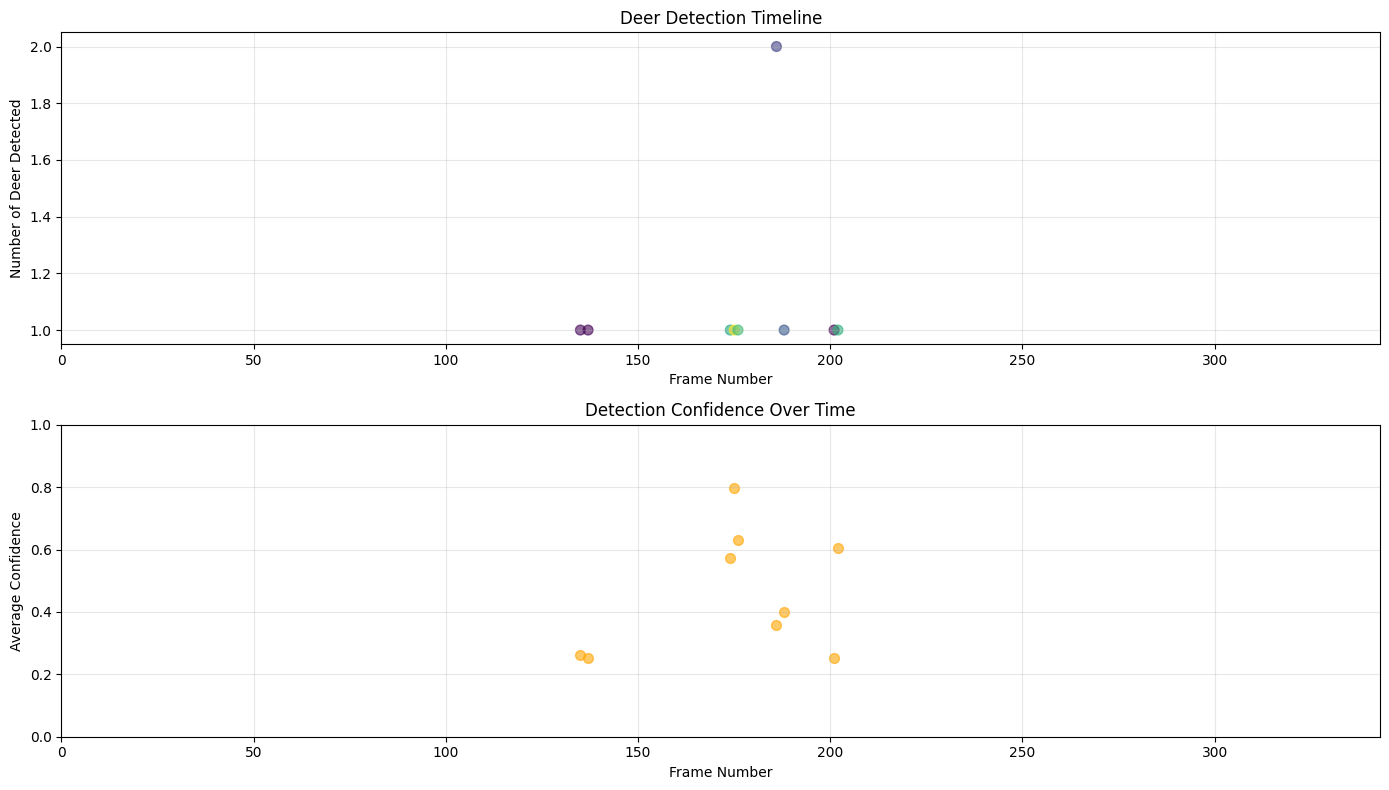


✅ Complete! Download the video from: /content/deer_detector/video_detections/test.mp4
   Or view it in: /content/deer_detector/video_detections


In [30]:
# Video inference with streaming and inline display
from ultralytics import YOLO
from pathlib import Path
import cv2
import numpy as np
from IPython.display import HTML, display
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load the trained model
best_model_path = MODEL_DIR / 'yolov8n_deer' / 'weights' / 'best.pt'
if best_model_path.exists():
    model = YOLO(str(best_model_path))
    print(f"✓ Loaded model: {best_model_path}")
else:
    print("❌ Model not found. Please complete training first.")
    model = None

# Video file path
video_path = PROJECT_DIR / "test.mp4"
if not video_path.exists():
    video_path = Path("/content/test.mp4")
    if not video_path.exists():
        print("⚠️  Please upload test.mp4 to Colab")
        print("   Use: from google.colab import files; files.upload()")

if model and video_path.exists():
    print(f"✓ Processing video: {video_path}")

    # Get video info first
    cap = cv2.VideoCapture(str(video_path))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps > 0 else 0
    cap.release()

    print(f"\n📹 Video Properties:")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {duration:.2f} seconds")

    # Process video with streaming to avoid RAM issues
    output_path = PROJECT_DIR / "video_detections" / video_path.name

    print(f"\n🎬 Processing video with streaming...")

    # Statistics tracking
    frame_detections = []  # List of (frame_num, num_detections, confidences)
    all_confidences = []
    frames_with_deer = 0
    total_detections = 0

    # Process with streaming
    results = model.predict(
        source=str(video_path),
        conf=0.25,  # Confidence threshold
        save=True,  # Save annotated video
        project=str(PROJECT_DIR),
        name="video_detections",
        show=False,
        verbose=False,  # Suppress per-frame output
        stream=True,  # Stream results to avoid RAM issues
    )

    # Process stream and collect statistics
    print("Processing frames...")
    for frame_idx, result in enumerate(tqdm(results, total=total_frames, desc="Frames")):
        num_detections = len(result.boxes)

        if num_detections > 0:
            frames_with_deer += 1
            total_detections += num_detections

            # Get confidences
            confidences = result.boxes.conf.cpu().numpy()
            all_confidences.extend(confidences.tolist())

            frame_detections.append({
                'frame': frame_idx + 1,
                'detections': num_detections,
                'confidences': confidences.tolist(),
                'avg_confidence': float(confidences.mean())
            })

    # Print comprehensive statistics
    print(f"\n✅ Video processing complete!")
    print(f"\n📊 Detection Statistics:")
    print(f"  Total frames processed: {total_frames}")
    print(f"  Frames with deer detected: {frames_with_deer} ({frames_with_deer/total_frames*100:.1f}%)")
    print(f"  Total deer detections: {total_detections}")

    if all_confidences:
        print(f"\n  Confidence Statistics:")
        print(f"    Average: {np.mean(all_confidences):.3f}")
        print(f"    Median: {np.median(all_confidences):.3f}")
        print(f"    Min: {np.min(all_confidences):.3f}")
        print(f"    Max: {np.max(all_confidences):.3f}")
        print(f"    Std Dev: {np.std(all_confidences):.3f}")

    # Show frames with detections
    if frame_detections:
        print(f"\n📸 Frames with deer detections:")
        for det_info in frame_detections[:10]:  # Show first 10
            frame_num = det_info['frame']
            num_dets = det_info['detections']
            avg_conf = det_info['avg_confidence']
            print(f"  Frame {frame_num}: {num_dets} deer (avg conf: {avg_conf:.3f})")
        if len(frame_detections) > 10:
            print(f"  ... and {len(frame_detections) - 10} more frames")

    print(f"\n💾 Output video saved to: {output_path}")
    if output_path.exists():
        file_size_mb = output_path.stat().st_size / (1024 * 1024)
        print(f"   File size: {file_size_mb:.2f} MB")

    # Display video inline in Colab
    print(f"\n🎥 Displaying video with detections...")

    def show_video(video_path, width=640):
        """Display video inline in Colab"""
        video_file = open(video_path, 'rb').read()
        video_url = f"data:video/mp4;base64,{video_file.encode('base64')}"
        return HTML(f"""
        <video width={width} controls>
            <source src="{video_url}" type="video/mp4">
            Your browser does not support the video tag.
        </video>
        """)

    # Alternative: Use cv2 to create a simple preview
    print("\n📹 Creating preview frames...")
    cap = cv2.VideoCapture(str(output_path))

    # Get sample frames with detections
    sample_frames = []
    frame_idx = 0

    while cap.isOpened() and len(sample_frames) < 6:
        ret, frame = cap.read()
        if not ret:
            break

        # Check if this frame had detections
        frame_num = frame_idx + 1
        has_detections = any(d['frame'] == frame_num for d in frame_detections)

        if has_detections or frame_idx % (total_frames // 5) == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            sample_frames.append((frame_num, frame_rgb))

        frame_idx += 1

    cap.release()

    # Display sample frames
    if sample_frames:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()

        for idx, (frame_num, frame) in enumerate(sample_frames[:6]):
            axes[idx].imshow(frame)
            det_info = next((d for d in frame_detections if d['frame'] == frame_num), None)
            if det_info:
                title = f"Frame {frame_num}\n{det_info['detections']} deer (conf: {det_info['avg_confidence']:.2f})"
                axes[idx].set_title(title, color='green', fontweight='bold')
            else:
                axes[idx].set_title(f"Frame {frame_num}\n(no detections)", color='gray')
            axes[idx].axis('off')

        plt.tight_layout()
        plt.show()

    # Create detection timeline visualization
    if frame_detections:
        print("\n📈 Creating detection timeline...")
        frame_nums = [d['frame'] for d in frame_detections]
        num_dets = [d['detections'] for d in frame_detections]
        avg_confs = [d['avg_confidence'] for d in frame_detections]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

        # Timeline of detections
        ax1.scatter(frame_nums, num_dets, alpha=0.6, s=50, c=avg_confs, cmap='viridis')
        ax1.set_xlabel('Frame Number')
        ax1.set_ylabel('Number of Deer Detected')
        ax1.set_title('Deer Detection Timeline')
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, total_frames)

        # Confidence over time
        ax2.scatter(frame_nums, avg_confs, alpha=0.6, s=50, c='orange')
        ax2.set_xlabel('Frame Number')
        ax2.set_ylabel('Average Confidence')
        ax2.set_title('Detection Confidence Over Time')
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, total_frames)
        ax2.set_ylim(0, 1)

        plt.tight_layout()
        plt.show()

    print(f"\n✅ Complete! Download the video from: {output_path}")
    print(f"   Or view it in: {PROJECT_DIR / 'video_detections'}")

else:
    print("❌ Cannot process video. Check model and video file paths.")

## Next Steps: Integration with dsperse

After downloading the model files:

1. **Place files in correct location:**
   ```bash
   dsperse/models/deer_detector/
   ├── model.onnx
   └── input.json
   ```

2. **Test the model with dsperse:**
   ```bash
   # Analyze the model
   dsperse analyze --path dsperse/models/deer_detector/model.onnx
   
   # Slice the model (if needed)
   dsperse slice --path dsperse/models/deer_detector/model.onnx --output dsperse/models/deer_detector/slices
   
   # Run inference
   dsperse run --path dsperse/models/deer_detector/model.onnx --input dsperse/models/deer_detector/input.json
   ```

3. **Note on Object Detection Models:**
   - YOLOv8 is an object detection model (outputs bounding boxes, scores, classes)
   - This is more complex than classification models currently in dsperse
   - Model slicing and ZK proof generation may require additional considerations
   - The detection head outputs may need special handling in the zkML pipeline

4. **Model Specifications:**
   - Architecture: YOLOv8n (nano)
   - Input size: 640x640x3
   - Output: Detection results (boxes, scores, classes)
   - Model size: ~5-10 MB (ONNX)
   - Training: 30 epochs on wildlife 10-class dataset
   - Target class: Deer (class index 4)


✓ Found video: /content/deer_detector/test.mp4
✓ Loaded ONNX model: /content/deer_detector/models/model.onnx

📹 Video Properties:
  Resolution: 960x720
  FPS: 35
  Total frames: 343
  Duration: 9.80 seconds

🎬 Processing video...


Processing frames: 100%|██████████| 343/343 [01:02<00:00,  5.50it/s, detections=476, frames_w_deer=166]



✅ Video processing complete!

📊 Detection Statistics:
  Total frames processed: 343
  Frames with deer detected: 174 (50.7%)
  Total deer detections: 488
  Average confidence: 0.329
  Min confidence: 0.250
  Max confidence: 0.731

💾 Output video saved to: /content/deer_detector/test_detections.mp4
   File size: 4.89 MB

📸 Displaying sample frame...


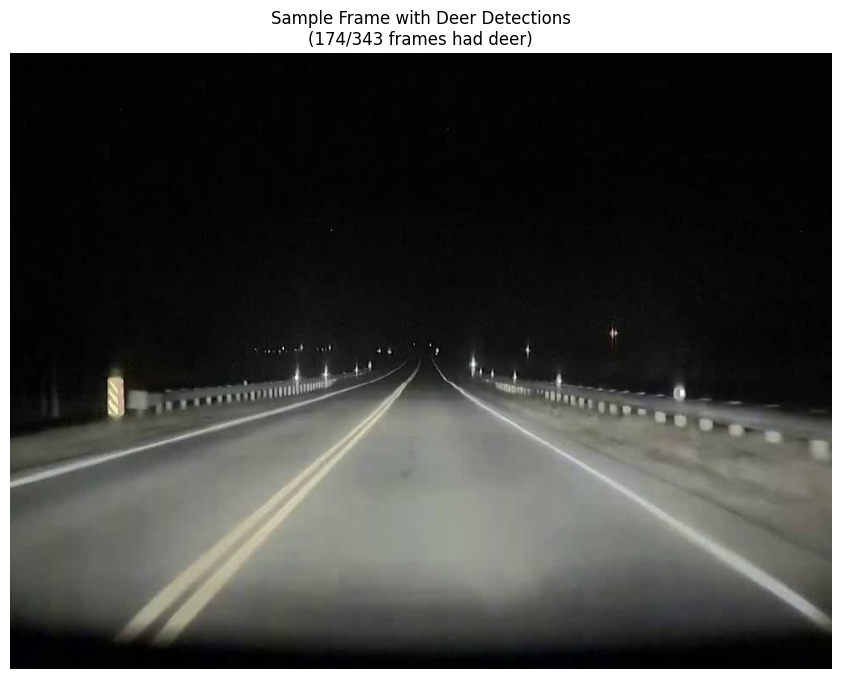

In [28]:
# Video inference with deer detection
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# Video file path (upload to Colab or use existing)
video_path = PROJECT_DIR / "test.mp4"

# If video not in project dir, try to find it
if not video_path.exists():
    # Try to find test.mp4 in current directory or uploads
    possible_paths = [
        Path("/content/test.mp4"),
        Path("/content/deer_detector/test.mp4"),
        Path("./test.mp4"),
    ]
    for path in possible_paths:
        if path.exists():
            video_path = path
            break

if not video_path.exists():
    print("⚠️  Video file not found. Please upload test.mp4 to Colab.")
    print("   You can drag and drop it in the file browser, or use:")
    print("   from google.colab import files")
    print("   uploaded = files.upload()")
else:
    print(f"✓ Found video: {video_path}")

    # Load ONNX model
    if onnx_path.exists():
        import onnxruntime as ort
        session = ort.InferenceSession(str(onnx_path))
        input_name = session.get_inputs()[0].name
        print(f"✓ Loaded ONNX model: {onnx_path}")
    else:
        # Try to load from weights directory
        weights_onnx = MODEL_DIR / 'yolov8n_deer' / 'weights' / 'best.onnx'
        if weights_onnx.exists():
            import onnxruntime as ort
            session = ort.InferenceSession(str(weights_onnx))
            input_name = session.get_inputs()[0].name
            onnx_path = weights_onnx
            print(f"✓ Loaded ONNX model: {weights_onnx}")
        else:
            print("❌ ONNX model not found. Please complete export step first.")
            session = None

    if session:
        # Open video
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            print(f"❌ Error: Could not open video {video_path}")
        else:
            # Get video properties
            fps = int(cap.get(cv2.CAP_PROP_FPS))
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            duration = total_frames / fps if fps > 0 else 0

            print(f"\n📹 Video Properties:")
            print(f"  Resolution: {width}x{height}")
            print(f"  FPS: {fps}")
            print(f"  Total frames: {total_frames}")
            print(f"  Duration: {duration:.2f} seconds")

            # Create output video
            output_path = PROJECT_DIR / "test_detections.mp4"
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

            # Detection statistics
            total_detections = 0
            frames_with_deer = 0
            detection_confidences = []

            print(f"\n🎬 Processing video...")

            frame_count = 0
            with tqdm(total=total_frames, desc="Processing frames") as pbar:
                while cap.isOpened():
                    ret, frame = cap.read()
                    if not ret:
                        break

                    # Preprocess frame for YOLOv8
                    # Resize to model input size (640x640) while maintaining aspect ratio
                    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    img_resized = cv2.resize(img_rgb, (img_size, img_size))

                    # Normalize to [0, 1] and convert to CHW format
                    img_array = img_resized.astype(np.float32) / 255.0
                    img_array = img_array.transpose(2, 0, 1)  # HWC to CHW
                    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

                    # Run inference
                    outputs = session.run(None, {input_name: img_array})

                    # YOLOv8 output format: (1, 5, 8400) where 5 = [x, y, w, h, conf]
                    # or (1, 6, 8400) with class_id
                    predictions = outputs[0][0]  # Remove batch dimension: (5, 8400) or (6, 8400)

                    # Process detections
                    frame_detections = 0
                    if predictions.shape[0] >= 5:
                        # Extract boxes and scores
                        boxes_xywh = predictions[:4, :].T  # (8400, 4) - x, y, w, h in normalized [0,1]
                        confidences = predictions[4, :]  # (8400,)

                        # Filter by confidence threshold
                        conf_threshold = 0.25
                        valid_mask = confidences > conf_threshold
                        valid_boxes = boxes_xywh[valid_mask]
                        valid_confidences = confidences[valid_mask]

                        # Scale boxes back to original frame size
                        scale_x = width / img_size
                        scale_y = height / img_size

                        # Draw detections on frame
                        for box, conf in zip(valid_boxes, valid_confidences):
                            # Convert from center x, center y, width, height to x1, y1, x2, y2
                            cx, cy, w, h = box
                            x1 = int((cx - w/2) * scale_x)
                            y1 = int((cy - h/2) * scale_y)
                            x2 = int((cx + w/2) * scale_x)
                            y2 = int((cy + h/2) * scale_y)

                            # Clip to frame boundaries
                            x1 = max(0, min(x1, width))
                            y1 = max(0, min(y1, height))
                            x2 = max(0, min(x2, width))
                            y2 = max(0, min(y2, height))

                            # Draw bounding box
                            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

                            # Draw label
                            label = f"Deer {conf:.2f}"
                            label_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                            cv2.rectangle(frame, (x1, y1 - label_size[1] - 10),
                                        (x1 + label_size[0], y1), (0, 255, 0), -1)
                            cv2.putText(frame, label, (x1, y1 - 5),
                                      cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

                            frame_detections += 1
                            total_detections += 1
                            detection_confidences.append(float(conf))

                        if frame_detections > 0:
                            frames_with_deer += 1

                    # Write frame to output video
                    out.write(frame)

                    frame_count += 1
                    pbar.update(1)

                    # Show progress every 30 frames
                    if frame_count % 30 == 0:
                        pbar.set_postfix({
                            'detections': total_detections,
                            'frames_w_deer': frames_with_deer
                        })

            # Release resources
            cap.release()
            out.release()

            # Print statistics
            print(f"\n✅ Video processing complete!")
            print(f"\n📊 Detection Statistics:")
            print(f"  Total frames processed: {frame_count}")
            print(f"  Frames with deer detected: {frames_with_deer} ({frames_with_deer/frame_count*100:.1f}%)")
            print(f"  Total deer detections: {total_detections}")
            if detection_confidences:
                print(f"  Average confidence: {np.mean(detection_confidences):.3f}")
                print(f"  Min confidence: {np.min(detection_confidences):.3f}")
                print(f"  Max confidence: {np.max(detection_confidences):.3f}")

            print(f"\n💾 Output video saved to: {output_path}")
            print(f"   File size: {output_path.stat().st_size / (1024*1024):.2f} MB")

            # Display a sample frame with detections
            print(f"\n📸 Displaying sample frame...")
            cap = cv2.VideoCapture(str(output_path))
            ret, sample_frame = cap.read()
            cap.release()

            if ret:
                sample_frame_rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)
                plt.figure(figsize=(12, 8))
                plt.imshow(sample_frame_rgb)
                plt.title(f"Sample Frame with Deer Detections\n({frames_with_deer}/{frame_count} frames had deer)")
                plt.axis('off')
                plt.show()